In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_977601/ipykernel_2673032/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [ ]:
# Load the entire model (architecture + weights)
# model = torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt")

In [ ]:
# model = model.to(device)

In [ ]:
# Set the model to evaluation mode (important for inference)
# model.eval()

In [5]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1310720), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 1, 130305]            --
├─StochasticReverseComplement: 1-1       [2, 4, 1310720]           --
├─StochasticShift: 1-2                   [2, 4, 1310720]           --
├─ConvBlock: 1-3                         [2, 128, 655360]          --
│    └─Conv1d: 2-1                       [2, 128, 1310720]         7,680
│    └─BatchNorm1d: 2-2                  [2, 128, 1310720]         256
│    └─MaxPool1d: 2-3                    [2, 128, 655360]          --
├─ConvTower: 1-4                         [2, 128, 640]             --
│    └─Sequential: 2-4                   [2, 128, 640]             --
│    │    └─ReLU: 3-1                    [2, 128, 655360]          --
│    │    └─Conv1d: 3-2                  [2, 128, 655360]          81,920
│    │    └─BatchNorm1d: 3-3             [2, 128, 655360]          256
│    │    └─MaxPool1d: 3-4               [2, 128, 327680]          --
│    │

In [6]:
from pyfaidx import Fasta

In [7]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

region = "chr12"
start = 115163136
end = start + 1310720

# region = "chr11"
# start = 75429888
# end = 76478464

# region = "chr15"
# start = 63281152
# end = 64329728

In [8]:
sequence = genome[region][start:end]

In [9]:
import numpy as np

In [10]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()

    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    # Step 1: Encode the sequence to integers
    encoded_sequence = np.array([base_to_int[base] for base in sequence])

    # Step 2: One-hot encode the sequence
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand the dimensions to [1, 4, sequence_length]
    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [ ]:
# background_file = f"/project2/fudenber_735/smaruj/akitaX1_analyses_data/background_generation/background_generation/background_sequences_model_0.fa"

In [ ]:
# background_seqs = []
    
# with open(background_file, "r") as f:
#     for line in f.readlines():
#         if ">" in line:
#             continue
#         background_seqs.append(one_hot_encode_sequence(line.strip()))

In [11]:
# X = background_seqs[0]

X = one_hot_encode_sequence(sequence)

In [12]:
# Convert the NumPy array to a PyTorch tensor
X_tensor = torch.tensor(X).to("cuda:0")

In [ ]:
# torch.save(X_tensor, "/scratch1/smaruj/ledidi_targets/full_map_optimization/X_background.pt")

In [13]:
model.eval()
with torch.no_grad():
    y = model(X_tensor)

In [14]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [15]:
y.shape

torch.Size([1, 1, 130305])

In [16]:
target0 = y[0,0,:]

In [17]:
matrix = from_upper_triu(target0, matrix_len=512, num_diags=2)

<Figure size 800x800 with 0 Axes>

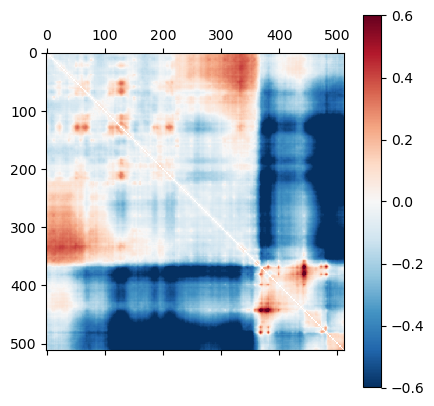

In [18]:
import matplotlib.pyplot as plt

# Plot the matrix
plt.figure(figsize=(8, 8))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.title('Heatmap of the Matrix')
# plt.savefig("background_map.svg", format='svg')
plt.show()

In [ ]:
np.nanmean(matrix[:256,256:])

In [ ]:
size = 512
c = -0.5
boundary = np.zeros((size, size))
half = size // 2

# creating a boundary
boundary[:half, half:] = c
boundary[half:, :half] = c

In [ ]:
# Create a blank mask
fragment_mask = np.zeros((size, size), dtype=bool)

# Mark the specified fragment
fragment_mask[:half, half:] = True
fragment_mask[half:, :half] = True

In [ ]:
import numpy as np

def fragment_indices_in_upper_triangular(matrix_size=512, fragment_mask=None):
    """
    Given a binary mask for a fragment in a (448, 448) matrix, find the corresponding indices 
    within the upper triangular output vector (excluding the first two diagonals).

    Parameters:
        matrix_size (int): The size of the square matrix (default: 448).
        fragment_mask (np.ndarray): A boolean mask of shape (448, 448) marking the fragment.

    Returns:
        np.ndarray: Indices in the upper triangular vector corresponding to the fragment.
    """
    if fragment_mask.shape != (matrix_size, matrix_size):
        raise ValueError("Fragment mask must be of shape (448, 448).")

    # Get the upper triangular indices skipping two diagonals
    row_indices, col_indices = np.triu_indices(matrix_size, k=2)
    
    # Identify which of these indices are in the fragment
    selected_indices = np.where(fragment_mask[row_indices, col_indices])[0]
    
    return selected_indices


In [ ]:
# Get the indices within the upper triangular vector
fragment_indices = fragment_indices_in_upper_triangular(matrix_size=size, fragment_mask=fragment_mask)

In [ ]:
fragment_indices_tensor = torch.tensor(fragment_indices)

In [ ]:
# np.save("./fragment_indices.npy", fragment_indices)
torch.save(fragment_indices_tensor, "/scratch1/smaruj/ledidi_targets/constant_boundary_background/boundary_indices.pt")

In [ ]:
fragment_indices.shape

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(boundary.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Constant Boundary')
plt.show()

In [19]:
def upper_triangular_to_vector_skip_two_diagonals(matrix):
    """
    Extracts the upper triangular part of a square matrix (excluding the first two diagonals) 
    and transforms it into a vector.
    
    Parameters:
        matrix (np.ndarray): A 2D numpy matrix of shape (512, 512).
        
    Returns:
        np.ndarray: A 1D array containing the upper triangular elements (excluding the first two diagonals).
    """
    if matrix.shape != (512, 512):
        raise ValueError("Input matrix must be of shape (512, 512).")
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(512, k=2)]
    
    return upper_triangular_vector

In [ ]:
strong_up_triu = upper_triangular_to_vector_skip_two_diagonals(boundary)

In [ ]:
y_cpu = y.cpu()

In [ ]:
y_cpu.shape

In [ ]:
y_bar_cpu = y_cpu.clone().detach()

# y_bar_cpu[:, :5, :] = y_cpu[:, :5, :] + strong_up_triu
# changing just one target
# y_bar_cpu[:, :, :] = y_cpu[:, :, :]
y_bar_cpu[0, 0, :] += strong_up_triu

In [ ]:
goal = matrix + boundary

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(goal.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Desired Matrix')
# plt.savefig("background__desired_map.svg", format='svg')
plt.show()

In [ ]:
modified_vector = torch.tensor(y_bar_cpu)

In [ ]:
modified_vector_tensor = modified_vector.to(device)

In [21]:
# torch.save(modified_vector_tensor, "/scratch1/smaruj/ledidi_targets/constant_boundary_background/boundary_-0.5.pt")

torch.save(y, "/scratch1/smaruj/ledidi_targets/full_map_optimization/genomic_map_vector.pt")

In [ ]:
target = modified_vector_tensor[0,0,:]

In [ ]:
test_matrix = from_upper_triu(target, matrix_len=512, num_diags=2)

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(test_matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Desired Matrix')
plt.show()

In [ ]:
def store_tower_output(ohe_sequence, model):
    x = model.conv_block_1(ohe_sequence)
    x = model.conv_tower(x)
    # save the tensor
    print(x.shape)
    torch.save(x, "/scratch1/smaruj/ledidi_targets/constant_boundary_background/tower_out.pt")
    torch.cuda.empty_cache()

In [ ]:
store_tower_output(X_tensor, model)